In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('default')
sns.set_theme()

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving global_green_energy_pulse_20260112.csv to global_green_energy_pulse_20260112.csv


In [ ]:
df = pd.read_csv("global_green_energy_pulse_20260112.csv")

print("Kích thước dữ liệu:", df.shape)

df.head()

Kích thước dữ liệu: (1920, 7)


,city,time,shortwave_radiation,wind_speed_100m,green_score,latitude,longitude
0,New York,2026-01-05 00:00:00,0.0,22.9,0.763333,40.71,-74.0
1,New York,2026-01-05 01:00:00,0.0,23.4,0.780000,40.71,-74.0
2,New York,2026-01-05 02:00:00,0.0,28.2,0.940000,40.71,-74.0
3,New York,2026-01-05 03:00:00,0.0,30.0,1.000000,40.71,-74.0
4,New York,2026-01-05 04:00:00,0.0,29.7,0.990000,40.71,-74.0


In [ ]:
print("Thông tin dataset:\n")
print(df.info())

print("\nSố lượng giá trị thiếu:")
print(df.isna().sum())


Thông tin dataset:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1920 entries, 0 to 1919
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   city                 1920 non-null   object 
 1   time                 1920 non-null   object 
 2   shortwave_radiation  1920 non-null   float64
 3   wind_speed_100m      1920 non-null   float64
 4   green_score          1920 non-null   float64
 5   latitude             1920 non-null   float64
 6   longitude            1920 non-null   float64
dtypes: float64(5), object(2)
memory usage: 105.1+ KB
None

Số lượng giá trị thiếu:
city                   0
time                   0
shortwave_radiation    0
wind_speed_100m        0
green_score            0
latitude               0
longitude              0
dtype: int64


In [ ]:
print("Số dòng trước khi làm sạch:", len(df))

df = df.dropna(subset=[
    'shortwave_radiation',
    'wind_speed_100m',
    'green_score'
])

print("Số dòng sau khi làm sạch:", len(df))


Số dòng trước khi làm sạch: 1920
Số dòng sau khi làm sạch: 1920


In [ ]:
print("Thống kê mô tả cho các biến quan tâm:\n")

print(df[['shortwave_radiation',
          'wind_speed_100m',
          'green_score']].describe())


Thống kê mô tả cho các biến quan tâm:

       shortwave_radiation  wind_speed_100m  green_score
count          1920.000000      1920.000000  1920.000000
mean            151.361615        21.030000     0.852362
std             249.820722        12.921166     0.482430
min               0.000000         0.400000     0.013333
25%               0.000000        10.800000     0.500450
50%               0.000000        19.000000     0.783333
75%             216.200000        28.100000     1.138517
max            1081.000000        71.400000     2.683667


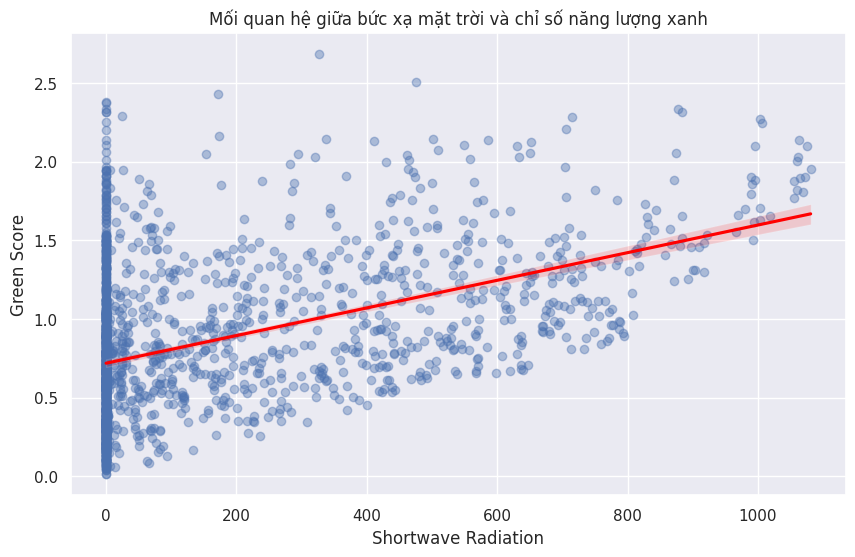

Hệ số tương quan: 0.455


In [ ]:
plt.figure(figsize=(10,6))

sns.regplot(
    data=df,
    x='shortwave_radiation',
    y='green_score',
    scatter_kws={'alpha':0.4},
    line_kws={'color':'red'}
)

plt.title("Mối quan hệ giữa bức xạ mặt trời và chỉ số năng lượng xanh")
plt.xlabel("Shortwave Radiation")
plt.ylabel("Green Score")

plt.show()

corr1 = df['shortwave_radiation'].corr(df['green_score'])
print("Hệ số tương quan:", round(corr1,3))


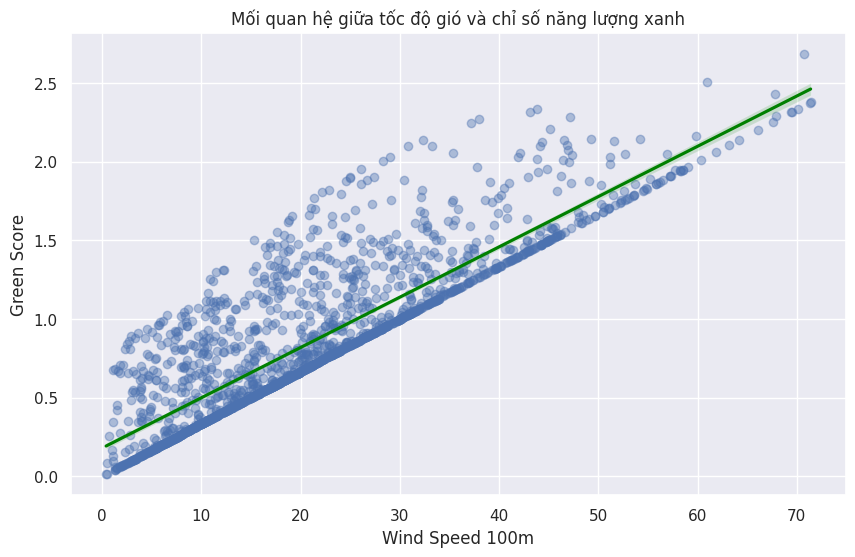

Hệ số tương quan: 0.856


In [ ]:
plt.figure(figsize=(10,6))

sns.regplot(
    data=df,
    x='wind_speed_100m',
    y='green_score',
    scatter_kws={'alpha':0.4},
    line_kws={'color':'green'}
)

plt.title("Mối quan hệ giữa tốc độ gió và chỉ số năng lượng xanh")
plt.xlabel("Wind Speed 100m")
plt.ylabel("Green Score")

plt.show()

corr2 = df['wind_speed_100m'].corr(df['green_score'])
print("Hệ số tương quan:", round(corr2,3))


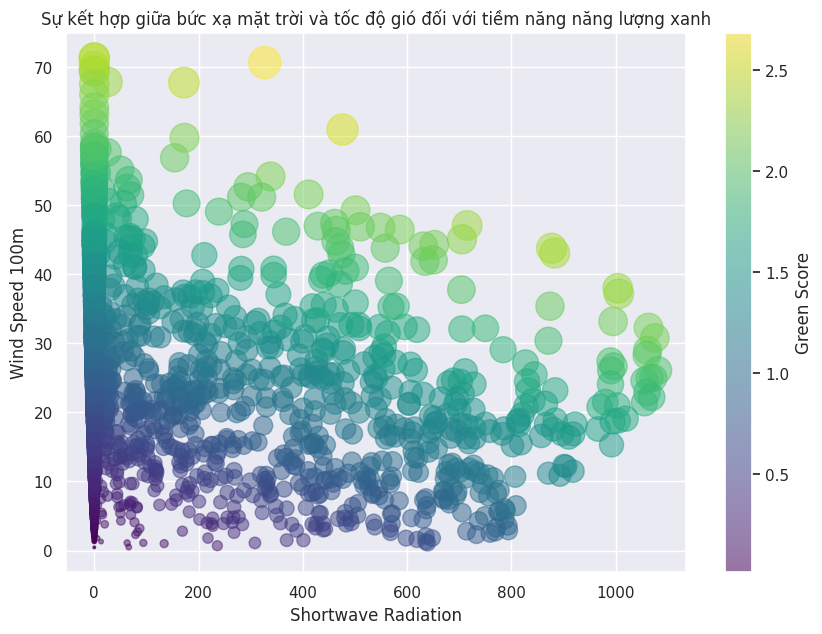

In [ ]:
plt.figure(figsize=(10,7))

scatter = plt.scatter(
    df['shortwave_radiation'],
    df['wind_speed_100m'],
    c=df['green_score'],
    s=df['green_score']*200,
    alpha=0.5,
    cmap='viridis'
)

plt.colorbar(scatter, label='Green Score')

plt.title("Sự kết hợp giữa bức xạ mặt trời và tốc độ gió đối với tiềm năng năng lượng xanh")
plt.xlabel("Shortwave Radiation")
plt.ylabel("Wind Speed 100m")

plt.show()
